In [1]:
import logging
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

from tqdm import tqdm
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")

In [2]:
# 1. Load Price Data and Market Cap Data
csv_file_path = "/Users/jacsonchong/Documents/NUS/AY2025 2026 Semester 2/FE5214/Project/codebase/data_cn/adjusted.csv"
df_prices = pd.read_csv(csv_file_path)
df_prices['Date'] = pd.to_datetime(df_prices['Date'], format='%Y%m%d')
df_prices.set_index('Date', inplace=True)

mcap_file_path = "/Users/jacsonchong/Documents/NUS/AY2025 2026 Semester 2/FE5214/Project/codebase/data_cn/mktcap.csv" 
df_mcap = pd.read_csv(mcap_file_path)
df_mcap['Date'] = pd.to_datetime(df_mcap['Date'], format='%Y%m%d')
df_mcap.set_index('Date', inplace=True)


In [3]:
# Copy and clean
prices = df_prices.copy()
prices.index = pd.to_datetime(prices.index)
prices = prices.sort_index()
prices = prices[~prices.index.duplicated(keep="last")]
prices = prices.apply(pd.to_numeric, errors="coerce")
prices = prices.replace([np.inf, -np.inf], np.nan)

def internal_missing_count(s):
    valid = s.notna().to_numpy()
    if not valid.any():
        return 0
    first = np.argmax(valid)
    last = len(valid) - 1 - np.argmax(valid[::-1])
    return int(s.iloc[first:last+1].isna().sum())

def max_drawdown(s):
    s = s.dropna()
    if s.empty:
        return np.nan
    dd = s / s.cummax() - 1
    return dd.min()

print(f"Shape: {prices.shape}")
print(f"Date range: {prices.index.min().date()} to {prices.index.max().date()}")
print(f"Duplicate dates removed: {df_prices.index.duplicated().sum()}")
print(f"Average missingness: {prices.isna().mean().mean() * 100:.2f}%")

Shape: (4859, 915)
Date range: 2006-01-04 to 2025-12-31
Duplicate dates removed: 0
Average missingness: 21.45%


In [4]:
coverage = pd.DataFrame({
    "n_obs": prices.notna().sum(),
    "missing_pct": prices.isna().mean() * 100,
    "first_date": prices.apply(lambda s: s.first_valid_index()),
    "last_date": prices.apply(lambda s: s.last_valid_index()),
    "internal_missing": prices.apply(internal_missing_count),
}).sort_values("n_obs", ascending=False)

coverage["lifespan_days"] = (coverage["last_date"] - coverage["first_date"]).dt.days

coverage.tail(10)

,n_obs,missing_pct,first_date,last_date,internal_missing,lifespan_days
600296,227,95.328257,2006-01-04,2007-01-09,18,370.0
600205,209,95.698703,2006-01-04,2007-01-09,36,370.0
827063Q,170,96.501338,2006-01-04,2006-09-25,7,264.0
000956,53,98.909241,2006-01-04,2006-04-06,7,92.0
600002,53,98.909241,2006-01-04,2006-04-06,7,92.0
000406,53,98.909241,2006-01-04,2006-04-06,7,92.0
000866,53,98.909241,2006-01-04,2006-04-06,7,92.0
000618,21,99.567812,2006-01-04,2006-02-10,0,37.0
000817,0,100.000000,NaT,NaT,0,NaN
000763,0,100.000000,NaT,NaT,0,NaN


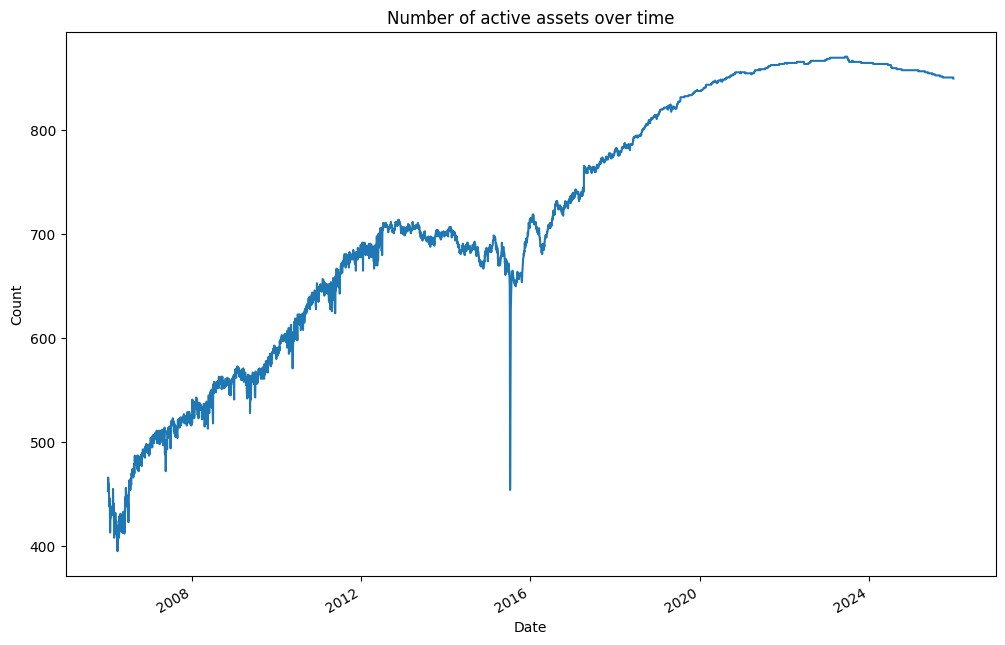

In [5]:
active_assets = prices.notna().sum(axis=1)

plt.figure(figsize=(12, 8))
active_assets.plot()
plt.title("Number of active assets over time")
plt.ylabel("Count")
plt.show()

In [6]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(active_assets)

Date
2006-01-04    453
2006-01-05    460
2006-01-06    466
2006-01-09    459
2006-01-10    459
2006-01-11    457
2006-01-12    460
2006-01-13    450
2006-01-16    439
2006-01-17    438
2006-01-18    441
2006-01-19    446
2006-01-20    444
2006-01-23    413
2006-01-24    419
2006-01-25    425
2006-02-06    432
2006-02-07    438
2006-02-08    433
2006-02-09    435
2006-02-10    434
2006-02-13    430
2006-02-14    434
2006-02-15    440
2006-02-16    443
2006-02-17    455
2006-02-20    433
2006-02-21    433
2006-02-22    435
2006-02-23    441
2006-02-24    433
2006-02-27    408
2006-02-28    413
2006-03-01    411
2006-03-02    421
2006-03-03    422
2006-03-06    412
2006-03-07    416
2006-03-08    419
2006-03-09    432
2006-03-10    427
2006-03-13    415
2006-03-14    417
2006-03-15    419
2006-03-16    423
2006-03-17    424
2006-03-20    413
2006-03-21    414
2006-03-22    413
2006-03-23    410
2006-03-24    412
2006-03-27    396
2006-03-28    395
2006-03-29    403
2006-03-30    408
2006-

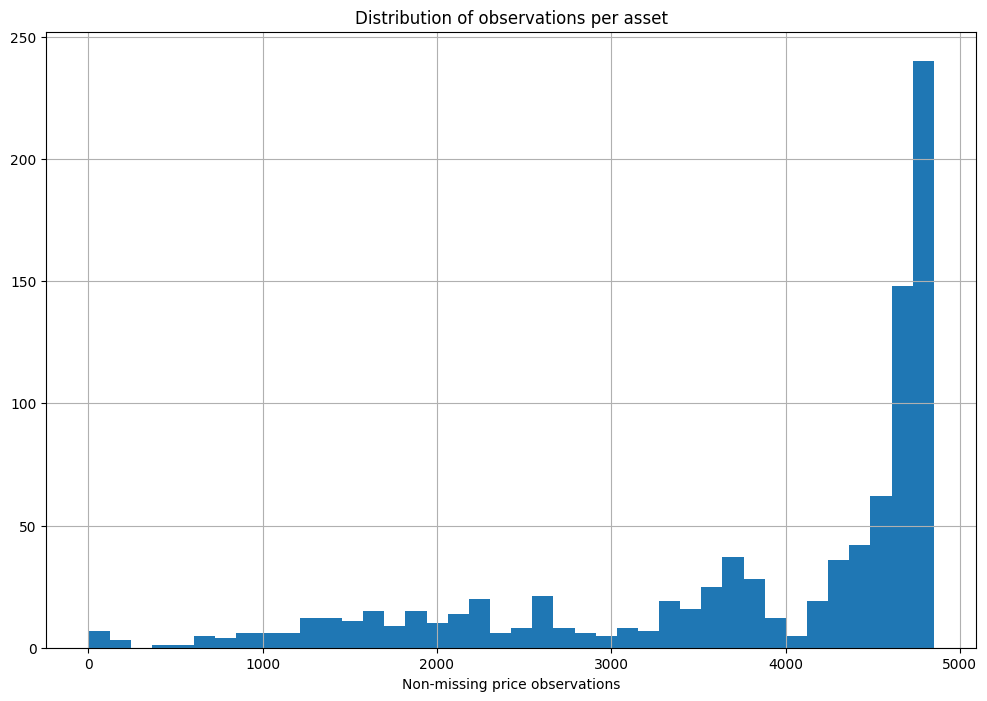

In [7]:
plt.figure(figsize=(12, 8))
coverage["n_obs"].hist(bins=40)
plt.title("Distribution of observations per asset")
plt.xlabel("Non-missing price observations")
plt.show()

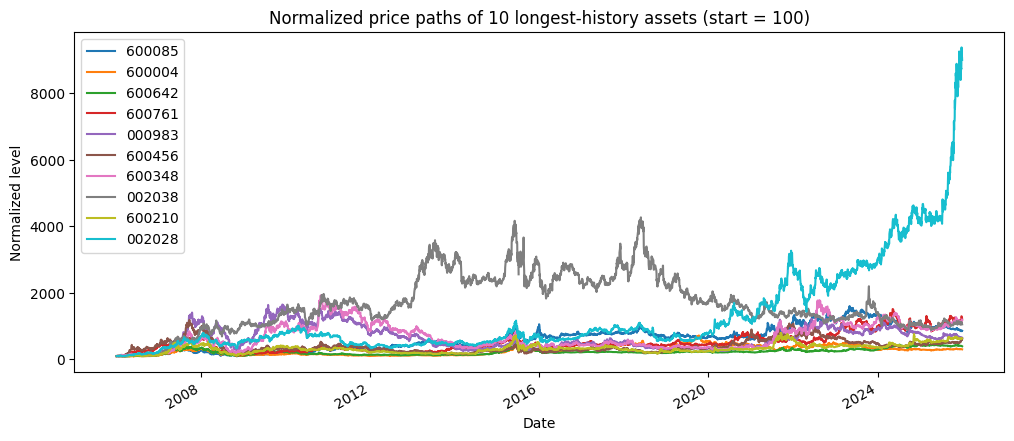

In [8]:
top10 = coverage.head(10).index
norm_prices = prices[top10].copy()

for c in top10:
    s = norm_prices[c].dropna()
    if not s.empty:
        norm_prices[c] = 100 * norm_prices[c] / s.iloc[0]

plt.figure(figsize=(12, 5))
norm_prices.plot(ax=plt.gca(), legend=False)
plt.title("Normalized price paths of 10 longest-history assets (start = 100)")
plt.ylabel("Normalized level")
plt.legend()
plt.show()

In [9]:
simple_ret = prices.div(prices.shift(1)) - 1
log_ret = np.log1p(simple_ret)

asset_stats = pd.DataFrame({
    "n_ret_obs": log_ret.notna().sum(),
    "ann_mean_log_ret": log_ret.mean() * 252,
    "ann_vol": log_ret.std() * np.sqrt(252),
    "skew": log_ret.skew(),
    "excess_kurtosis": log_ret.kurtosis(),
    "max_drawdown": prices.apply(max_drawdown),
}).join(
    coverage[["n_obs", "missing_pct", "internal_missing", "first_date", "last_date"]]
)

asset_stats["sharpe_proxy"] = asset_stats["ann_mean_log_ret"] / asset_stats["ann_vol"]

asset_stats[["ann_mean_log_ret", "ann_vol", "skew", "excess_kurtosis", "max_drawdown"]].describe()

,ann_mean_log_ret,ann_vol,skew,excess_kurtosis,max_drawdown
count,913.000000,913.000000,913.000000,913.000000,913.000000
mean,0.105913,0.455133,0.884084,25.879015,-0.785068
std,0.125313,0.079281,2.468304,78.043267,0.127139
min,-0.440975,0.019480,-14.629195,-0.431665,-0.996935
25%,0.042774,0.412216,-0.079609,2.392919,-0.862829
50%,0.090866,0.455126,0.051220,3.328425,-0.804780
75%,0.148522,0.498230,0.789199,10.358735,-0.738856
max,1.131057,0.855407,18.677903,811.428548,-0.001927


In [10]:
asset_stats.sort_values("ann_vol", ascending=False).head(10)

,n_ret_obs,ann_mean_log_ret,ann_vol,skew,excess_kurtosis,max_drawdown,n_obs,missing_pct,internal_missing,first_date,last_date,sharpe_proxy
688256,1325,0.579506,0.855407,8.519790,181.222335,-0.831972,1326,72.710434,0,2020-07-17,2025-12-31,0.677462
688111,1487,0.324721,0.708748,8.046758,178.092385,-0.678227,1488,69.376415,0,2019-11-15,2025-12-31,0.458161
688012,1566,0.361446,0.708615,7.993968,179.180816,-0.718871,1567,67.750566,0,2019-07-19,2025-12-31,0.510073
300896,1275,0.229517,0.699778,10.909072,258.872079,-0.765851,1276,73.739453,0,2020-09-25,2025-12-31,0.327985
002411,2969,-0.205957,0.699063,-14.629195,529.355594,-0.981754,2989,38.485285,202,2010-05-24,2023-07-11,-0.294619
688303,1079,0.075713,0.691607,13.076208,307.381129,-0.791362,1080,77.773204,0,2021-07-21,2025-12-31,0.109474
688126,1385,0.312718,0.690727,9.969369,228.934330,-0.805950,1386,71.475612,0,2020-04-17,2025-12-31,0.452738
688005,1566,0.117222,0.688989,2.223123,29.232421,-0.872328,1567,67.750566,0,2019-07-19,2025-12-31,0.170137
688008,1566,0.255611,0.684525,10.736943,275.789778,-0.630958,1567,67.750566,0,2019-07-19,2025-12-31,0.373413
688041,822,0.561989,0.679877,2.269411,27.188055,-0.496871,823,83.062359,0,2022-08-11,2025-12-31,0.826604


In [11]:
asset_stats.sort_values("max_drawdown").head(10)

,n_ret_obs,ann_mean_log_ret,ann_vol,skew,excess_kurtosis,max_drawdown,n_obs,missing_pct,internal_missing,first_date,last_date,sharpe_proxy
600804,4571,-0.098965,0.580338,-4.413431,118.394542,-0.996935,4607,5.186252,128,2006-01-04,2025-07-02,-0.170530
300104,1882,-0.254457,0.675252,0.269657,4.169855,-0.995874,1910,60.691500,505,2010-08-11,2020-07-20,-0.376833
600074,2648,-0.137743,0.555204,-0.083744,1.335185,-0.994081,2689,44.659395,814,2006-01-04,2020-06-02,-0.248094
600200,4714,-0.160856,0.582326,-6.285654,191.916175,-0.992864,4738,2.490224,120,2006-01-04,2025-12-30,-0.276231
002450,2356,-0.180927,0.461626,0.097209,11.129433,-0.992464,2374,51.142210,268,2010-07-15,2021-05-28,-0.391935
000939,2997,-0.224536,0.505810,-0.424847,1.874295,-0.987421,3042,37.394526,594,2006-01-04,2020-12-16,-0.443914
601558,2257,-0.440975,0.422151,-0.377571,3.857197,-0.986821,2270,53.282568,32,2011-01-12,2020-07-02,-1.044591
000806,3959,-0.103008,0.517801,-1.777630,32.949722,-0.985799,3987,17.946079,263,2006-01-09,2023-07-05,-0.198934
600485,2669,-0.145469,0.584072,-0.190816,0.848122,-0.983664,2705,44.330109,785,2006-01-04,2020-05-14,-0.249059
002411,2969,-0.205957,0.699063,-14.629195,529.355594,-0.981754,2989,38.485285,202,2010-05-24,2023-07-11,-0.294619


In [12]:
ew_ret = simple_ret.mean(axis=1, skipna=True)
ew_index = (1 + ew_ret.fillna(0)).cumprod()
ew_vol_63 = ew_ret.rolling(63).std() * np.sqrt(252)
ew_drawdown = ew_index / ew_index.cummax() - 1
xsec_dispersion = simple_ret.std(axis=1)

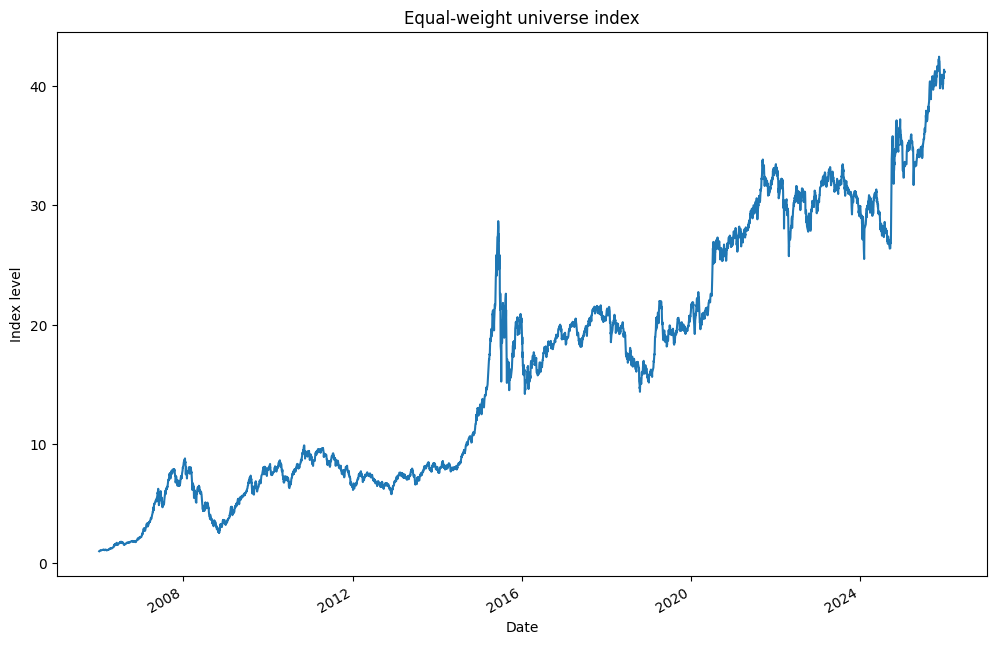

In [13]:
plt.figure(figsize=(12, 8))
ew_index.plot()
plt.title("Equal-weight universe index")
plt.ylabel("Index level")
plt.show()

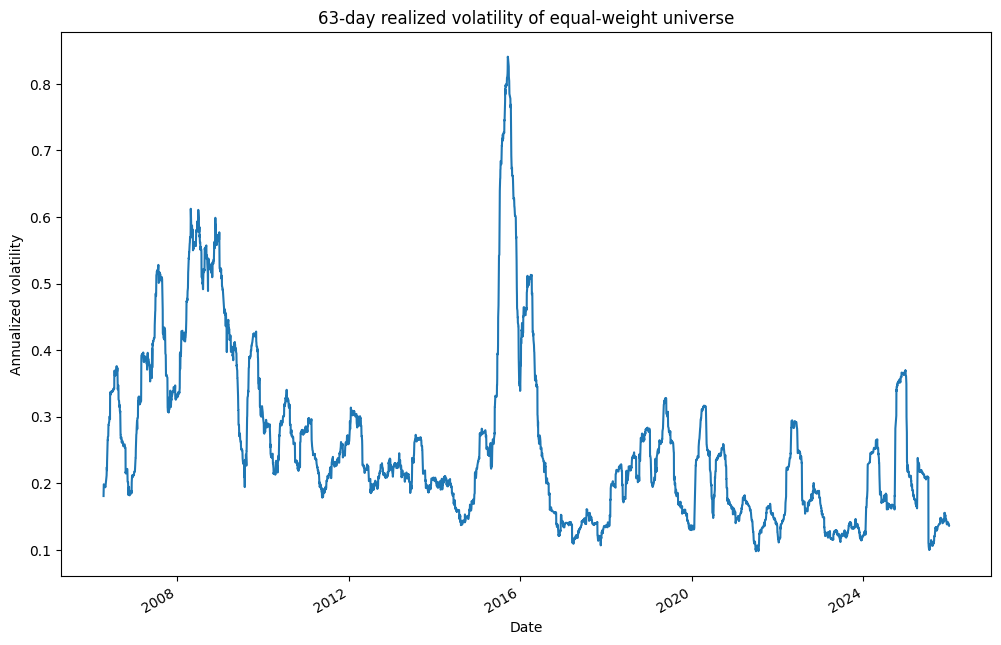

In [14]:
plt.figure(figsize=(12, 8))
ew_vol_63.plot()
plt.title("63-day realized volatility of equal-weight universe")
plt.ylabel("Annualized volatility")
plt.show()

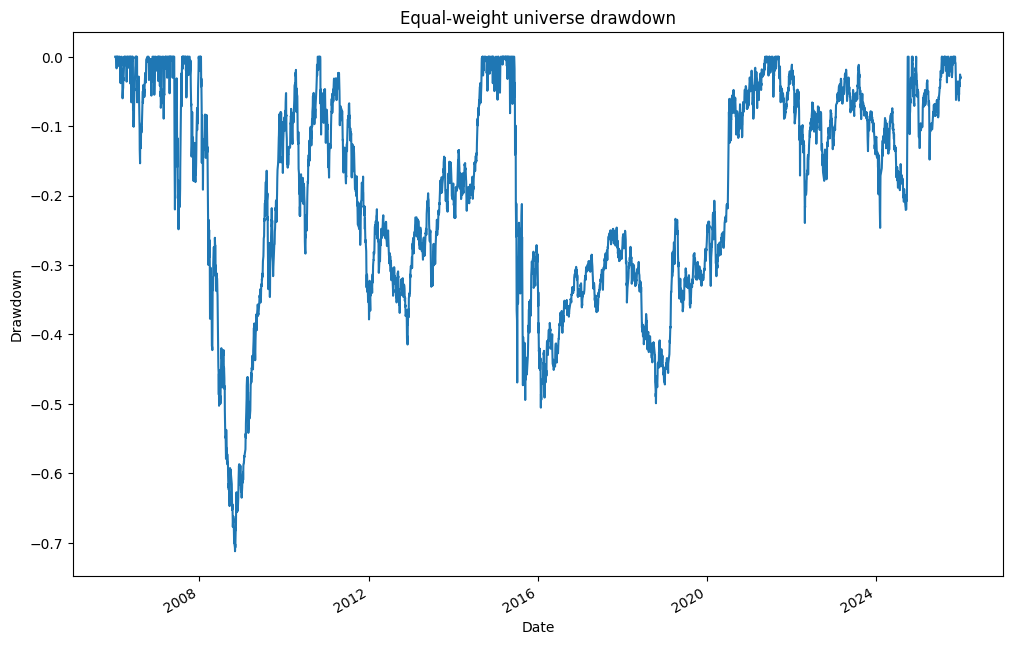

In [15]:
plt.figure(figsize=(12, 8))
ew_drawdown.plot()
plt.title("Equal-weight universe drawdown")
plt.ylabel("Drawdown")
plt.show()

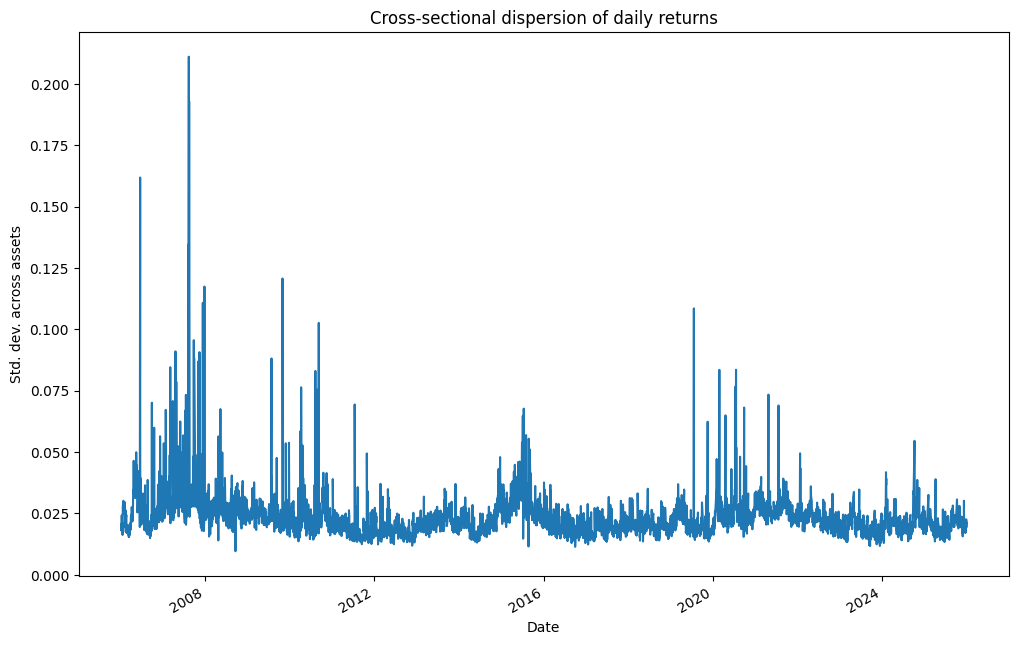

In [16]:
plt.figure(figsize=(12, 8))
xsec_dispersion.plot()
plt.title("Cross-sectional dispersion of daily returns")
plt.ylabel("Std. dev. across assets")
plt.show()

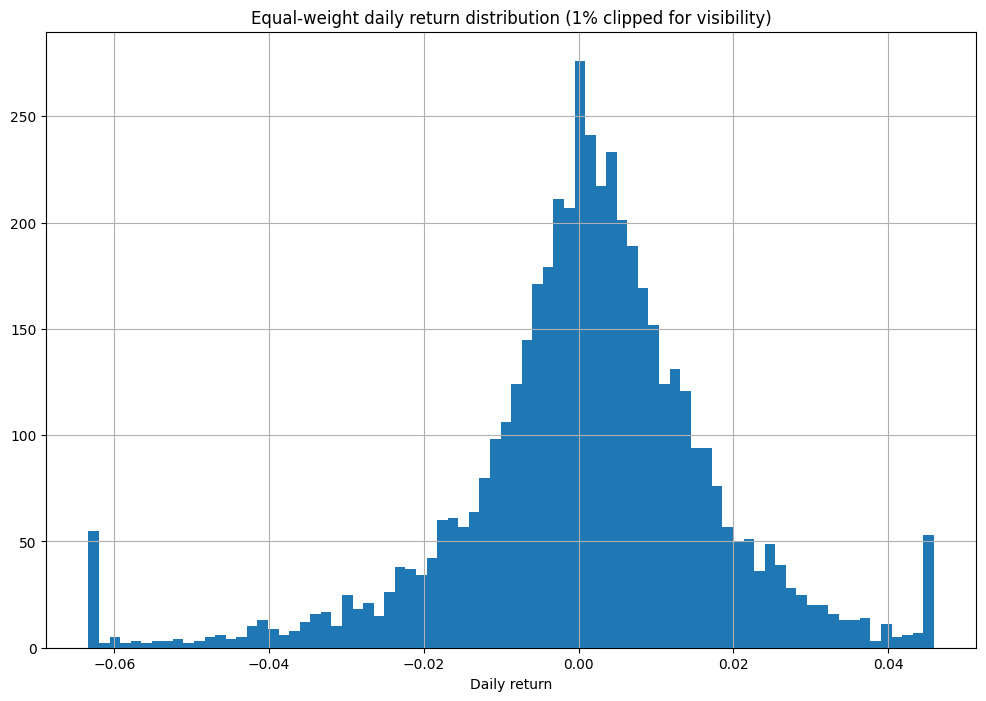

In [17]:
plt.figure(figsize=(12, 8))
ew_ret.dropna().clip(
    lower=ew_ret.quantile(0.01),
    upper=ew_ret.quantile(0.99)
).hist(bins=80)
plt.title("Equal-weight daily return distribution (1% clipped for visibility)")
plt.xlabel("Daily return")
plt.show()

In [18]:
jb = jarque_bera(ew_ret.dropna())
lb_ret = acorr_ljungbox(ew_ret.dropna(), lags=[5, 10, 20], return_df=True)
lb_sq = acorr_ljungbox((ew_ret.dropna() ** 2), lags=[5, 10, 20], return_df=True)

market_diag = pd.Series({
    "mean_daily_return": ew_ret.mean(),
    "daily_volatility": ew_ret.std(),
    "annualized_volatility": ew_ret.std() * np.sqrt(252),
    "skew": ew_ret.skew(),
    "excess_kurtosis": ew_ret.kurtosis(),
    "jarque_bera_pvalue": getattr(jb, "pvalue", jb[1]),
    "lb_ret_pvalue_lag5": lb_ret.loc[5, "lb_pvalue"],
    "lb_ret_pvalue_lag10": lb_ret.loc[10, "lb_pvalue"],
    "lb_sqret_pvalue_lag5": lb_sq.loc[5, "lb_pvalue"],
    "lb_sqret_pvalue_lag10": lb_sq.loc[10, "lb_pvalue"],
})

market_diag

mean_daily_return        0.000928
daily_volatility         0.017941
annualized_volatility    0.284802
skew                    -0.656267
excess_kurtosis          4.949393
jarque_bera_pvalue       0.000000
lb_ret_pvalue_lag5       0.000002
lb_ret_pvalue_lag10      0.000002
lb_sqret_pvalue_lag5     0.000000
lb_sqret_pvalue_lag10    0.000000
dtype: float64

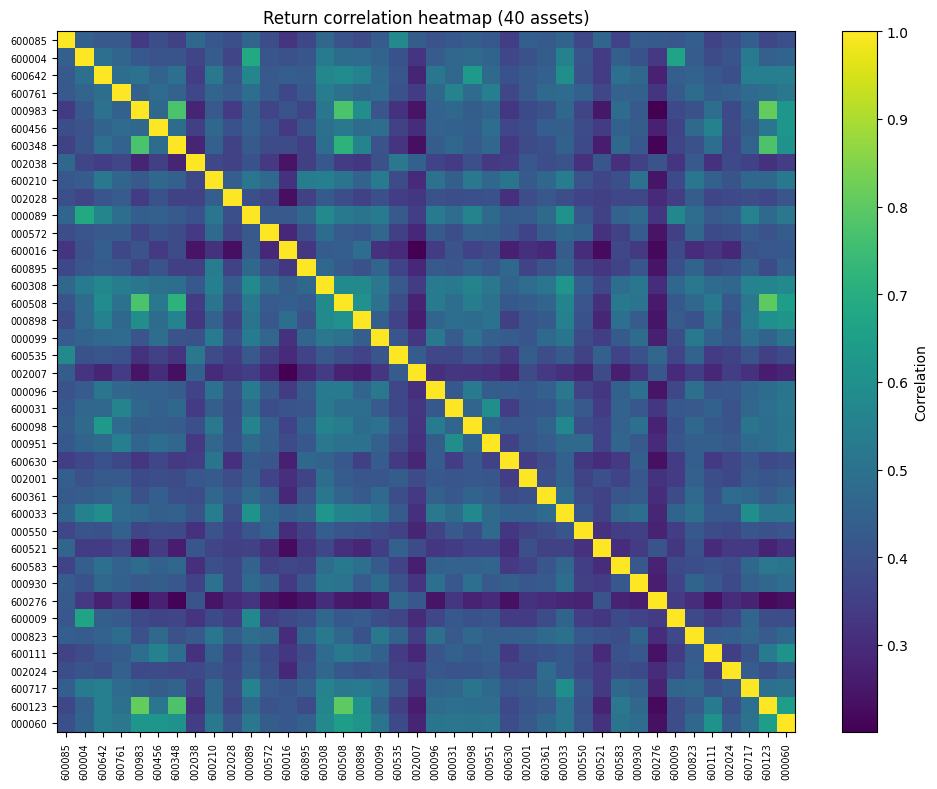

In [19]:
corr_cols = coverage.loc[coverage["n_obs"] >= 252].head(40).index
corr_mat = log_ret[corr_cols].corr(min_periods=252)

plt.figure(figsize=(10, 8))
plt.imshow(corr_mat, aspect="auto")
plt.colorbar(label="Correlation")
plt.title(f"Return correlation heatmap ({len(corr_cols)} assets)")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90, fontsize=7)
plt.yticks(range(len(corr_cols)), corr_cols, fontsize=7)
plt.tight_layout()
plt.show()

In [20]:
median_pairwise_corr = corr_mat.where(
    np.triu(np.ones(corr_mat.shape), k=1).astype(bool)
).stack().median()

print(f"Median pairwise correlation: {median_pairwise_corr:.4f}")

Median pairwise correlation: 0.4203


In [21]:
regime_proxy = pd.DataFrame({
    "ew_ret": ew_ret,
    "ew_vol_63": ew_vol_63,
    "xsec_dispersion": xsec_dispersion,
    "active_assets": active_assets,
}).dropna()

regime_proxy["vol_bucket"] = pd.qcut(
    regime_proxy["ew_vol_63"],
    q=3,
    labels=["Low Vol", "Mid Vol", "High Vol"],
    duplicates="drop"
)

regime_summary = regime_proxy.groupby("vol_bucket").agg({
    "ew_ret": ["mean", "std", "min", "max"],
    "xsec_dispersion": ["mean", "median"],
    "active_assets": ["mean", "min"]
})

regime_summary

ew_ret                               xsec_dispersion            \
                mean       std       min       max            mean    median   
vol_bucket                                                                     
Low Vol     0.000464  0.009664 -0.046881  0.050388        0.021066  0.020298   
Mid Vol     0.000884  0.014874 -0.086817  0.056474        0.022096  0.020613   
High Vol    0.001326  0.025654 -0.097999  0.098230        0.026408  0.024150   

           active_assets       
                    mean  min  
vol_bucket                     
Low Vol       813.934334  423  
Mid Vol       726.541302  413  
High Vol      627.185116  412

In [22]:
def build_cap_weighted_market_index(df_prices, df_mcap, base=100.0, vol_window=20, annualization=252):
    """
    Build a market-cap-weighted return series and index level.

    Parameters
    ----------
    df_prices : DataFrame
        Adjusted close prices, indexed by date, columns=tickers
    df_mcap : DataFrame
        Market caps, same structure as df_prices
    base : float
        Starting index level
    vol_window : int
        Rolling window for annualized volatility
    annualization : int
        Trading days per year, typically 252

    Returns
    -------
    out : DataFrame
        Columns:
        - market_cap_weighted_return
        - market_cap_weighted_index
        - rolling_20d_ann_vol
    weights : DataFrame
        Daily lagged cap weights used in the index
    asset_ret : DataFrame
        Constituent daily simple returns
    """
    prices = df_prices.copy()
    mcaps = df_mcap.copy()

    # Basic cleaning
    prices.index = pd.to_datetime(prices.index)
    mcaps.index = pd.to_datetime(mcaps.index)

    prices = prices.sort_index()
    mcaps = mcaps.sort_index()

    prices = prices[~prices.index.duplicated(keep="last")]
    mcaps = mcaps[~mcaps.index.duplicated(keep="last")]

    prices = prices.apply(pd.to_numeric, errors="coerce")
    mcaps = mcaps.apply(pd.to_numeric, errors="coerce")

    # Keep only common dates and common tickers
    common_dates = prices.index.intersection(mcaps.index)
    common_tickers = prices.columns.intersection(mcaps.columns)

    prices = prices.loc[common_dates, common_tickers]
    mcaps = mcaps.loc[common_dates, common_tickers]

    # Invalid caps should not be used
    mcaps = mcaps.where(mcaps > 0)

    # Simple returns for index construction
    # fill_method=None prevents forward-filling through missing prices
    asset_ret = prices.pct_change(fill_method=None)

    # Lag caps by one day to avoid look-ahead bias
    lagged_mcaps = mcaps.shift(1)

    # Only use names where both today's return and yesterday's market cap are available
    valid = asset_ret.notna() & lagged_mcaps.notna()
    effective_caps = lagged_mcaps.where(valid)

    # Re-normalize across available names each day
    weights = effective_caps.div(effective_caps.sum(axis=1), axis=0)

    # Market-cap-weighted daily return
    market_ret = (weights * asset_ret).sum(axis=1, min_count=1)

    # Turn return series into an index level
    market_index = base * (1 + market_ret.fillna(0.0)).cumprod()

    # Rolling annualized volatility
    rolling_vol = (
        market_ret.rolling(vol_window, min_periods=vol_window).std()
        * np.sqrt(annualization)
    )

    out = pd.DataFrame({
        "market_cap_weighted_return": market_ret,
        "market_cap_weighted_index": market_index,
        "rolling_20d_ann_vol": rolling_vol
    })

    return out, weights, asset_ret

In [23]:
market_df, weights, asset_ret = build_cap_weighted_market_index(
    df_prices=df_prices,
    df_mcap=df_mcap,
    base=100.0,
    vol_window=20,
    annualization=252
)

In [24]:
print("Number of common tickers:", len(df_prices.columns.intersection(df_mcap.columns)))
print("Number of common dates:", len(df_prices.index.intersection(df_mcap.index)))

print("\nWeight sum check (should be very close to 1 on valid days):")
print(weights.sum(axis=1).dropna().describe())

Number of common tickers: 914
Number of common dates: 4859

Weight sum check (should be very close to 1 on valid days):
count    4859.000000
mean        0.999794
std         0.014346
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
dtype: float64


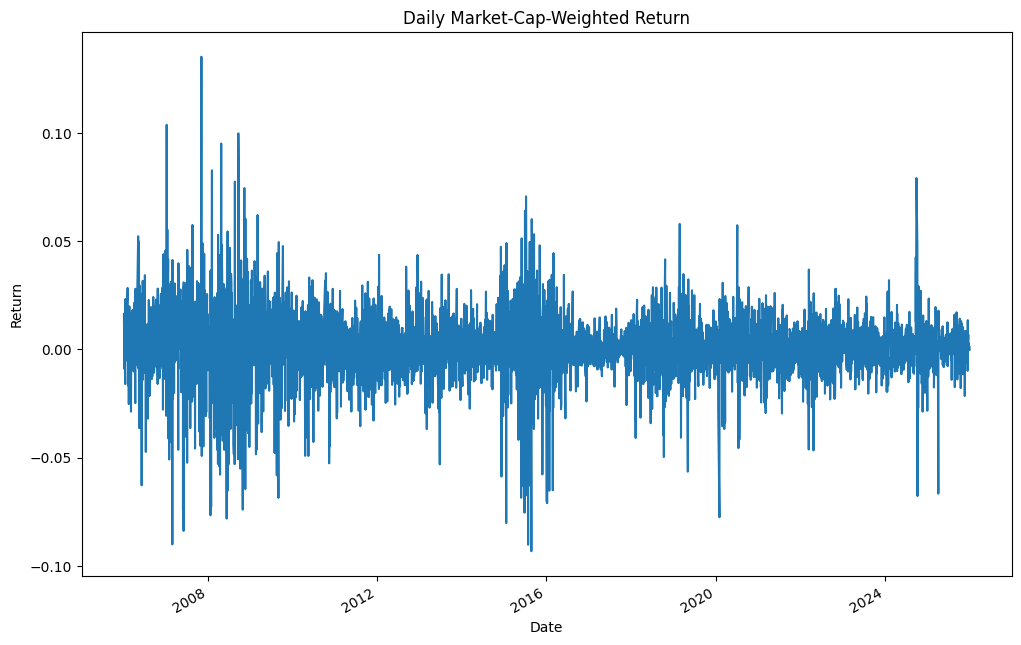

In [25]:
plt.figure(figsize=(12, 8))
market_df["market_cap_weighted_return"].plot()
plt.title("Daily Market-Cap-Weighted Return")
plt.ylabel("Return")
plt.show()

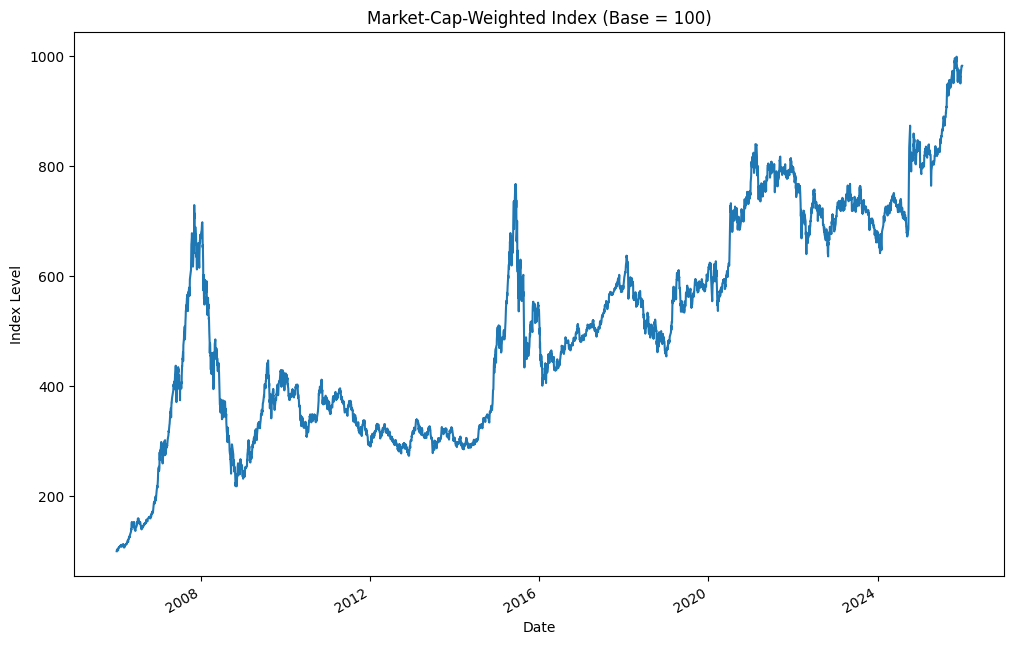

In [26]:
plt.figure(figsize=(12, 8))
market_df["market_cap_weighted_index"].plot()
plt.title("Market-Cap-Weighted Index (Base = 100)")
plt.ylabel("Index Level")
plt.show()

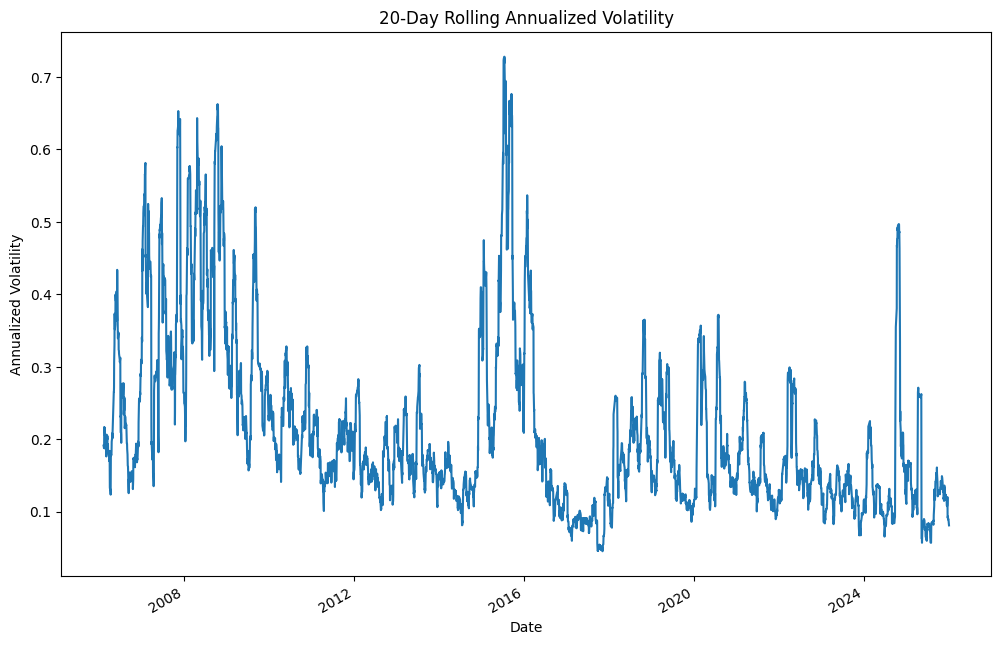

In [27]:
plt.figure(figsize=(12, 8))
market_df["rolling_20d_ann_vol"].plot()
plt.title("20-Day Rolling Annualized Volatility")
plt.ylabel("Annualized Volatility")
plt.show()

In [28]:
market_df["market_cap_weighted_log_return"] = np.log1p(
    market_df["market_cap_weighted_return"]
)

In [29]:
market_df

,market_cap_weighted_return,market_cap_weighted_index,rolling_20d_ann_vol,market_cap_weighted_log_return
Date,,,,
2006-01-04,NaN,100.000000,NaN,NaN
2006-01-05,0.016368,101.636751,NaN,0.016235
2006-01-06,0.008855,102.536717,NaN,0.008816
2006-01-09,0.003718,102.917938,NaN,0.003711
2006-01-10,0.004693,103.400883,NaN,0.004682
...,...,...,...,...
2025-12-25,0.002574,979.545699,0.089433,0.002570
2025-12-26,0.002385,981.882243,0.089579,0.002382
2025-12-29,-0.000432,981.457947,0.085153,-0.000432


# Sector wide Correlation

In [30]:
tickers = pd.read_csv("/Users/jacsonchong/Documents/NUS/AY2025 2026 Semester 2/FE5214/Project/codebase/data_cn/tickers.csv", header=None)
tickers.columns = ['ticker', 'gics']

# Standard GICS slicing
tickers["sector"] = tickers["gics"].apply(lambda x: str(x)[:2] if pd.notna(x) else None)
tickers["industry_group"] = tickers["gics"].apply(lambda x: str(x)[:4] if pd.notna(x) else None)
tickers["industry"] = tickers["gics"].apply(lambda x: str(x)[:6] if pd.notna(x) else None)

In [31]:
def prepare_returns_and_sector_lookup(df_prices, tickers, sector_col="sector", return_type="simple"):
    prices = df_prices.copy()
    prices.index = pd.to_datetime(prices.index)
    prices = prices.sort_index()
    prices = prices.apply(pd.to_numeric, errors="coerce")
    prices.columns = prices.columns.astype(str)

    if return_type == "log":
        returns = np.log(prices / prices.shift(1))
    else:
        returns = prices.pct_change(fill_method=None)

    mapping = (
        tickers[["ticker", sector_col]]
        .dropna(subset=["ticker", sector_col])
        .drop_duplicates(subset="ticker")
        .copy()
    )
    mapping["ticker"] = mapping["ticker"].astype(str)

    sector_lookup = mapping.set_index("ticker")[sector_col]
    sector_lookup = sector_lookup.reindex(returns.columns).dropna()

    returns = returns.loc[:, sector_lookup.index]
    returns = returns.dropna(how="all")

    return returns, sector_lookup


def build_sector_return_matrix(df_prices, tickers, sector_col="sector", return_type="simple", min_names=3):
    returns, sector_lookup = prepare_returns_and_sector_lookup(
        df_prices, tickers, sector_col=sector_col, return_type=return_type
    )

    # Equal-weight daily sector return
    sector_returns = returns.T.groupby(sector_lookup).mean().T

    # Number of valid constituents per sector per day
    sector_counts = returns.notna().astype(int).T.groupby(sector_lookup).sum().T

    # Keep sector return only when enough stocks are present that day
    sector_returns = sector_returns.where(sector_counts >= min_names)

    # Drop sectors that become entirely empty
    sector_returns = sector_returns.dropna(axis=1, how="all")

    return sector_returns, sector_counts


def plot_corr_heatmap(corr, title="Pairwise Correlation Across Sectors", annotate=True):
    labels = corr.columns.astype(str).tolist()

    fig_w = max(8, 1.0 * len(labels))
    fig_h = max(6, 0.8 * len(labels))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")

    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Correlation")

    if annotate and len(labels) <= 15:
        for i in range(len(labels)):
            for j in range(len(labels)):
                val = corr.iat[i, j]
                if pd.notna(val):
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

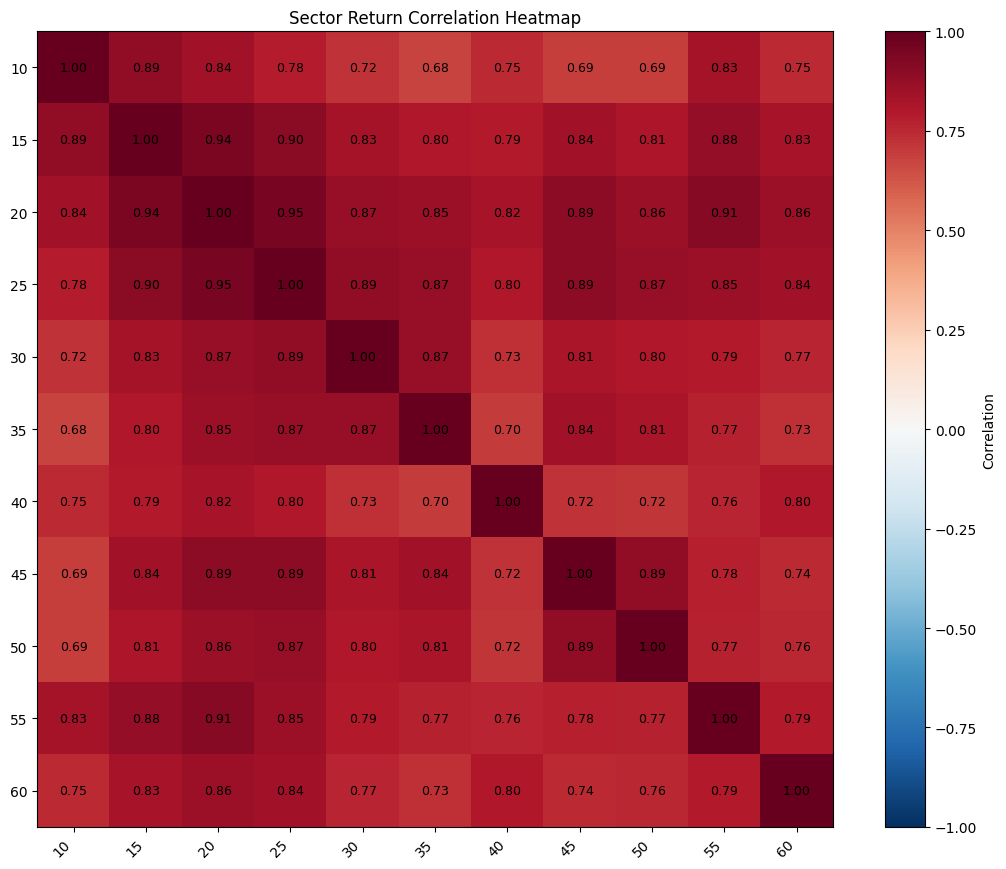

In [32]:
# For true sector-level GICS correlation:
sector_returns, sector_counts = build_sector_return_matrix(
    df_prices,
    tickers,
    sector_col="sector",      # use "industry_group" if you want 4-digit grouping
    return_type="log",        # "simple" also fine
    min_names=3
)

sector_corr = sector_returns.corr(min_periods=60)
sector_corr = sector_corr.sort_index(axis=0).sort_index(axis=1)

plot_corr_heatmap(sector_corr, title="Sector Return Correlation Heatmap")

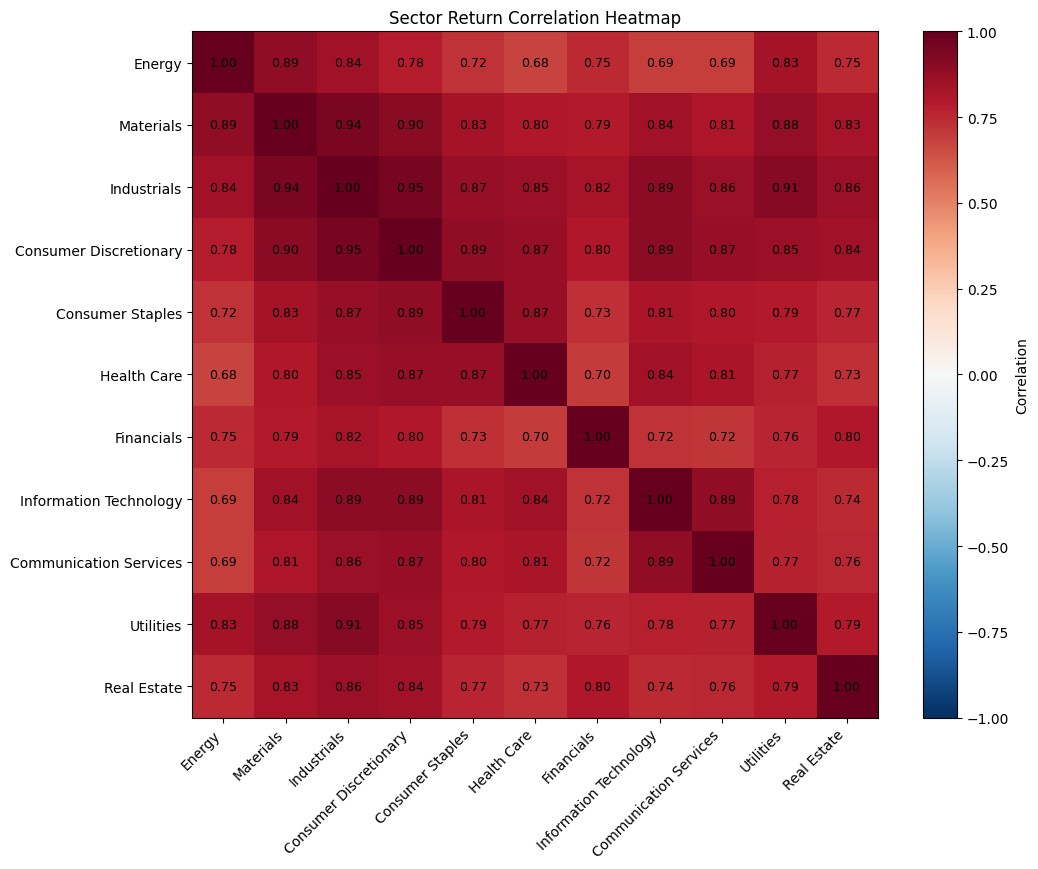

In [33]:
gics_sector_names = {
    "10": "Energy",
    "15": "Materials",
    "20": "Industrials",
    "25": "Consumer Discretionary",
    "30": "Consumer Staples",
    "35": "Health Care",
    "40": "Financials",
    "45": "Information Technology",
    "50": "Communication Services",
    "55": "Utilities",
    "60": "Real Estate",
}

sector_corr_named = sector_corr.rename(index=gics_sector_names, columns=gics_sector_names)
plot_corr_heatmap(sector_corr_named, title="Sector Return Correlation Heatmap")

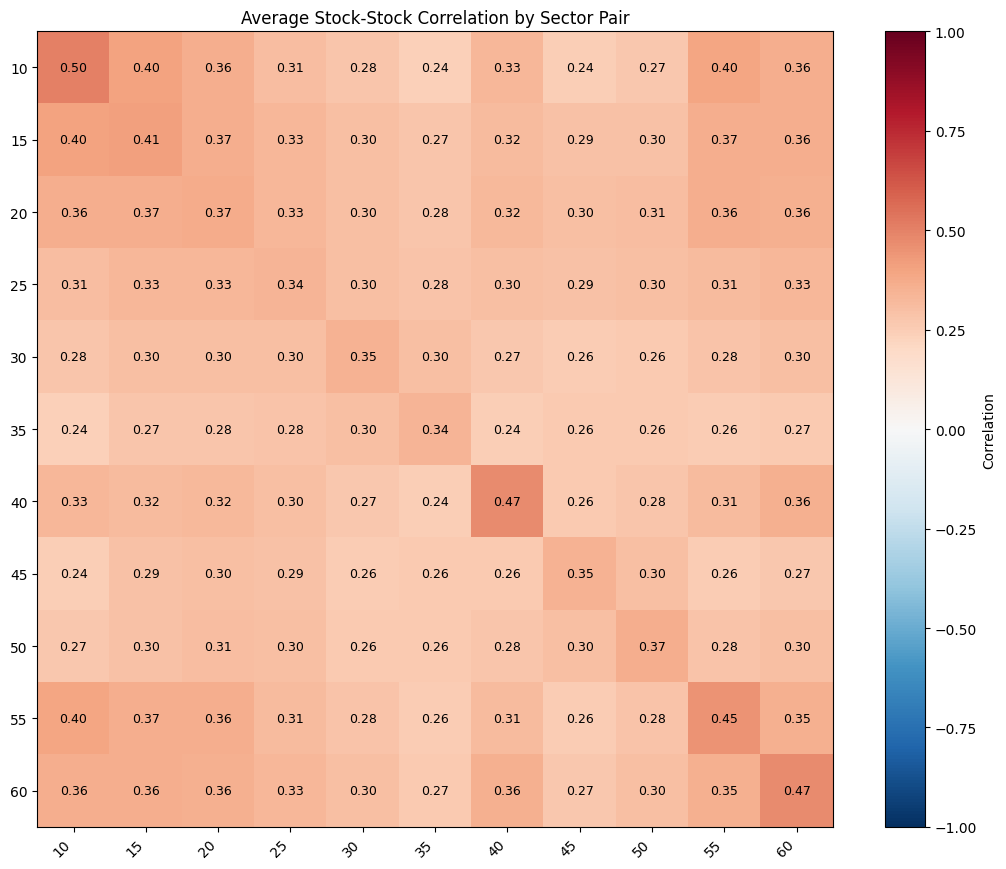

In [34]:
def build_sector_block_correlation(
    df_prices,
    tickers,
    sector_col="sector",
    return_type="simple",
    min_names=3,
    min_periods=60
):
    returns, sector_lookup = prepare_returns_and_sector_lookup(
        df_prices, tickers, sector_col=sector_col, return_type=return_type
    )

    members = sector_lookup.groupby(sector_lookup).apply(lambda s: list(s.index))
    members = members[members.apply(len) >= min_names]

    keep_tickers = [t for lst in members for t in lst]
    returns = returns[keep_tickers]

    asset_corr = returns.corr(min_periods=min_periods)

    sectors = members.index.tolist()
    out = pd.DataFrame(index=sectors, columns=sectors, dtype=float)

    for s1 in sectors:
        for s2 in sectors:
            block = asset_corr.loc[members[s1], members[s2]].to_numpy(dtype=float)

            if s1 == s2:
                # remove self-correlation on the diagonal
                mask = ~np.eye(len(members[s1]), dtype=bool)
                block = block[mask]
            else:
                block = block.ravel()

            block = block[~np.isnan(block)]
            out.loc[s1, s2] = block.mean() if block.size else np.nan

    return out


sector_block_corr = build_sector_block_correlation(
    df_prices,
    tickers,
    sector_col="sector",
    return_type="log",
    min_names=3,
    min_periods=60
)

plot_corr_heatmap(sector_block_corr, title="Average Stock-Stock Correlation by Sector Pair")